### Install Packages

In [14]:
!pip install torch --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.5 MB 991.0 kB/s eta 0:01:56
   ---------------------------------------- 0.1/114.5 MB 919.0 kB/s eta 0:02:05
   ---------------------------------------- 0.1/114.5 MB 1.1 MB/s eta 0:01:42
   ---------------------------------------- 0.2/114.5 MB 1.2 MB/s eta 0:01:37
   ---------------------------------------- 0.3/114.5 MB 1.4 MB/s eta 0:01:21
   ---------------------------------------- 0.4/114.5 MB 1.3 MB/s eta 0:01:25
   ---------------------------------------- 0.5/114.5 MB 1.4 MB/s eta 0:01:22
   ---------------------------------------- 0.5/114.5 MB 1.5 MB/s eta 0:01:17
   ---------------------------------------- 0.5/114.5 MB 1.5 MB/s eta 0:01:17
   ---------------------------------------- 0.6/114.5 MB 1.3 MB/s eta 0:01:29
   ---------------------------------------- 0.7/114.5 MB 1.4 MB/s eta 0:01:23
   -------

In [15]:
!uv pip install langchain langgraph langchain-community langchain-huggingface faiss-cpu sentence-transformers

Audited 6 packages in 101ms


### Cloud Models 

In [1]:
import os 

os.chdir("..")

In [2]:
### HANDLE ENVIRONMENT
from dotenv import load_dotenv

load_dotenv(dotenv_path=r".env")

True

In [3]:
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings

llm = ChatBedrockConverse(
    model=os.getenv("AWS_Nova_Pro"), # AWS_LLAMA_3_3 - AWS_Nova_Pro - AWS_Nova_Lite
    temperature=0,
    max_tokens=2048,
    region_name=os.getenv("AWS_REGION")
)

embeddings = BedrockEmbeddings(
    model_id=os.getenv("AWS_TITAN_EMBED_V2"),
    region_name=os.getenv("AWS_REGION")
)

In [4]:
llm.invoke("hi there")

AIMessage(content="Hello! It's nice to have you here. How can I assist you today? Whether you have a question, need information on a specific topic, or just want to chat, feel free to let me know. I'm here to help!", additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '054131cb-54f6-4373-a8c2-7ddbe43f6c59', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Sat, 18 Apr 2026 15:52:53 GMT', 'content-type': 'application/json', 'content-length': '396', 'connection': 'keep-alive', 'x-amzn-requestid': '054131cb-54f6-4373-a8c2-7ddbe43f6c59'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [486]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.amazon.nova-pro-v1:0'}, id='lc_run--019da14b-7b92-7382-957c-c388249122bc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 52, 'total_tokens': 54, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}})

### Explore Data

In [5]:
import os 

os.chdir("..")

In [5]:
data_dir = r"data\selected"

os.listdir(data_dir)

['4G-Routers__889ccdfb.md',
 '5G-Devices-Mobile__2a97054a.md',
 'Accessories__b8334247.md',
 'Co-Location-Hosting__793c394f.md',
 'Contuct-Us-ar__95212594.md',
 'FAQ__59f00398.md',
 'Prepaid-Agda3-Sha7na__6e7bf09a.md',
 'Voice-Plans__41f20fa0.md',
 'WE-Business-Internet__7bdfb49e.md',
 'WE-Gold__3416ff59.md']

In [6]:
import re 

def extract_metadata_and_clean_content(content: str) -> tuple[str, dict]:
    """Extracts URL and Title from the --- block and returns clean content."""
    meta_pattern = r'---\s*url:\s*(.*?)\s*title:\s*(.*?)\s*---'
    match = re.search(meta_pattern, content, re.DOTALL | re.IGNORECASE)
    
    metadata = {"source_url": "No URL found", "title": "No Title found"}
    clean_content = content
    
    if match:
        metadata["source_url"] = match.group(1).strip()
        metadata["title"] = match.group(2).strip()
        clean_content = re.sub(meta_pattern, '', content, flags=re.DOTALL | re.IGNORECASE).strip()
        
    return clean_content, metadata

In [7]:
file_path = rf"{data_dir}\{os.listdir(data_dir)[0]}"

with open(file_path, "r") as f:
    data = f.read()

out1, out2 = extract_metadata_and_clean_content(data)
out2

{'source_url': 'https://te.eg/wps/portal/te/Personal/Devices/4G-Routers',
 'title': '4G-Routers'}

In [8]:
for i in os.listdir(data_dir):
    temp_file_path = rf"{data_dir}\{i}"

    with open(temp_file_path, "r", encoding="utf-8") as f:
        data = f.read()

    _, out2 = extract_metadata_and_clean_content(data)
    print( out2 )

{'source_url': 'https://te.eg/wps/portal/te/Personal/Devices/4G-Routers', 'title': '4G-Routers'}
{'source_url': 'https://te.eg/wps/portal/te/Personal/Devices/5G-Devices-Mobile', 'title': '5G Devices'}
{'source_url': 'https://te.eg/wps/portal/te/Personal/Devices/Accessories', 'title': 'Accessories'}
{'source_url': 'https://te.eg/wps/portal/te/Business/Hosting-Data-Center/Co-Location-Hosting', 'title': 'Data Center Co-Location'}
{'source_url': 'https://www.te.eg/wps/vanityurl/Contuct-Us-ar', 'title': 'إتصل بنا'}
{'source_url': 'https://www.te.eg/wps/portal/te/Personal/Help%20And%20Support%20l/FAQ/?1dmy=&urile=wcm%3Apath%3A%2FTE%2FHelp%2FFAQ%2F', 'title': 'FAQ\ufeff'}
{'source_url': 'https://te.eg/wps/portal/te/Personal/Mobile/Prepaid-Agda3-Sha7na', 'title': 'Agda3 Sha7na'}
{'source_url': 'https://www.te.eg/wps/portal/te/Business/Voice-Services/Voice-Plans', 'title': 'Voice Plans'}
{'source_url': 'https://www.te.eg/wps/portal/te/Business/Mobile-Services/WE-Business-Internet', 'title': 'WE

### Create Vector DB

In [5]:
import os
from typing import List, Dict, Any
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter
from langchain_core.documents import Document

In [ ]:
def load_embedding_model(model_name: str):
    """
    Initializes the embedding model and runs a quick sanity test.
    """
    print(f"--- Initializing Embedding Model: {model_name} ---")
    embeddings = HuggingFaceEmbeddings(model_name=model_name)
    
    # Sanity Test
    test_text = "Checking connection to embedding model..."
    test_vector = embeddings.embed_query(test_text)
    
    print(f"✅ Model loaded successfully.")
    print(f"🧪 Test Embedding Dimensions: {len(test_vector)}")
    print("-" * 50)
    
    return embeddings

In [15]:
model = load_embedding_model(r"Omartificial-Intelligence-Space/AraGemma-Embedding-300m")

--- Initializing Embedding Model: Omartificial-Intelligence-Space/AraGemma-Embedding-300m ---


c:\Users\hp\Documents\Python Scripts\We Bot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\hp\Documents\Python Scripts\We Bot\.venv\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [10]:
def chunk_markdown_file(file_path: str) -> List[Document]:
    """Reads a file and creates chunks with unique IDs."""
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    clean_text, meta = extract_metadata_and_clean_content(content)
    file_name = os.path.basename(file_path)
    
    headers_to_split_on = [("#", "Header 1"), ("##", "Header 2")]
    md_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
    sections = md_splitter.split_text(clean_text)

    child_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    
    final_documents = []
    chunk_counter = 0
    
    for section in sections:
        chunks = child_splitter.split_text(section.page_content)
        for chunk in chunks:
            unique_id = f"{file_name}_{chunk_counter}"
            combined_metadata = {
                **section.metadata, 
                **meta, 
                "file_name": file_name,
                "chunk_id": unique_id
            }
            final_documents.append(Document(page_content=chunk, metadata=combined_metadata))
            chunk_counter += 1

    return final_documents

In [11]:
chunks = chunk_markdown_file(file_path)
chunks

[Document(metadata={'source_url': 'https://te.eg/wps/portal/te/Personal/Devices/4G-Routers', 'title': '4G-Routers', 'file_name': '4G-Routers__889ccdfb.md', 'chunk_id': '4G-Routers__889ccdfb.md_0'}, page_content='#### [5G ](https://te.eg/wps/portal/te/Personal/Devices/5G-Devices-Mobile)\n#### [Routers ](https://te.eg/wps/portal/te/Personal/Devices/Routers)\n#### [Fixed Landline Phones ](https://te.eg/wps/portal/te/Personal/Devices/Fixed-Landline-Phones)\n#### [USB modems ](https://te.eg/wps/portal/te/Personal/Devices/USB-Modems)\n#### [4G Routers ](https://te.eg/wps/portal/te/Personal/Devices/4G-Routers)\n#### [Mobile Phones ](https://te.eg/wps/portal/te/Personal/Devices/Mobile-Phones)'),
 Document(metadata={'source_url': 'https://te.eg/wps/portal/te/Personal/Devices/4G-Routers', 'title': '4G-Routers', 'file_name': '4G-Routers__889ccdfb.md', 'chunk_id': '4G-Routers__889ccdfb.md_1'}, page_content='#### [Accessories ](https://te.eg/wps/portal/te/Personal/Devices/Accessories)\n‹›\nFilter B

In [19]:
def create_local_faiss_db(documents: List[Document], embeddings: HuggingFaceEmbeddings, store_path: str):
    """Saves the FAISS index locally using the provided embeddings."""
    if not documents:
        print("❌ No documents found to index.")
        return

    vectorstore = FAISS.from_documents(documents, embeddings)
    vectorstore.save_local(store_path)
    print(f"✅ Successfully saved {len(documents)} chunks to '{store_path}'")
    return vectorstore

def run_pipeline(input_folder: str, db_name: str, model_name: str):
    """Main function to run the whole process."""
    # 1. Load Model
    embeddings = load_embedding_model(model_name)
    
    # 2. Process Files
    all_chunks = []
    if not os.path.exists(input_folder):
        print(f"❌ Error: Folder '{input_folder}' not found.")
        return

    for filename in os.listdir(input_folder):
        if filename.endswith(".md"):
            path = os.path.join(input_folder, filename)
            print(f"📄 Processing: {filename}")
            chunks = chunk_markdown_file(path)
            all_chunks.extend(chunks)
            print(f"📄 Processing: {filename} has {len(chunks)} of chunks")
    
    # 3. Create Vector DB
    return create_local_faiss_db(all_chunks, embeddings, db_name)

def run_pipeline_v2(input_folder: str, db_name: str, embeddings_model: any):
    """Main function to run the whole process."""
    all_chunks = []
    if not os.path.exists(input_folder):
        print(f"❌ Error: Folder '{input_folder}' not found.")
        return

    for filename in os.listdir(input_folder):
        if filename.endswith(".md"):
            path = os.path.join(input_folder, filename)
            print(f"📄 Processing: {filename}")
            chunks = chunk_markdown_file(path)
            all_chunks.extend(chunks)
            print(f"📄 Processing: {filename} has {len(chunks)} of chunks")
    
    # 3. Create Vector DB
    return create_local_faiss_db(all_chunks, embeddings_model, db_name)

In [ ]:
# --- CONFIGURATION ---
# MODEL_NAME = "all-MiniLM-L6-v2"  # You can change this to any HuggingFace model
EMBEDDING_MODEL = embeddings
SOURCE_FOLDER = r".\data\selected" 
DB_PATH = r"vectordb"

vector_db = run_pipeline_v2(SOURCE_FOLDER, DB_PATH, EMBEDDING_MODEL)

📄 Processing: 4G-Routers__889ccdfb.md
📄 Processing: 5G-Devices-Mobile__2a97054a.md
📄 Processing: Accessories__b8334247.md
📄 Processing: Co-Location-Hosting__793c394f.md
📄 Processing: Contuct-Us-ar__95212594.md
📄 Processing: FAQ__59f00398.md
📄 Processing: Prepaid-Agda3-Sha7na__6e7bf09a.md
📄 Processing: Voice-Plans__41f20fa0.md
📄 Processing: WE-Business-Internet__7bdfb49e.md
📄 Processing: WE-Gold__3416ff59.md
✅ Successfully saved 206 chunks to 'vectordb'


### utils

In [5]:
import time
from functools import wraps

def timeit(func):
    @wraps(func)
    def timeit_wrapper(*args, **kwargs):
        start_time = time.perf_counter()
        result = func(*args, **kwargs)
        end_time = time.perf_counter()
        total_time = end_time - start_time
        print(f'[INFO] Function {func.__name__}{args} {kwargs} Took {total_time:.4f} seconds')
        return result
    return timeit_wrapper

In [6]:
import threading
from typing import Any, Dict, List
from time import perf_counter

from langchain_core.callbacks import BaseCallbackHandler
from langchain_core.messages import AIMessage
from langchain_core.outputs import ChatGeneration, LLMResult


MODEL_COST_PER_1K_TOKENS = {
    "mixtral-8x7b-32768": 0.00024,
    "mixtral-8x7b-32768-completion": 0.00024,

    "llama-3.3-70b-versatile": 0.00059,
    "llama-3.3-70b-versatile-completion": 0.00079,
    "llama-3.1-8b-instant": 0.00005,
    "llama-3.1-8b-instant-completion": 0.00008,

    "deepseek-r1-distill-llama-70b": 0.00075,
    "deepseek-r1-distill-llama-70b-completion": 0.00099,

    "gemma2-9b-it": 0,
    "gemma2-9b-it-completion": 0,

    "us.amazon.nova-lite-v1:0": 0.00006,
    "us.amazon.nova-lite-v1:0-completion": 0.00024,

    "us.amazon.nova-pro-v1:0": 0.0008,
    "us.amazon.nova-pro-v1:0-completion": 0.0032,

    "us.amazon.nova-premier-v1:0": 0.0025,
    "us.amazon.nova-premier-v1:0-completion": 0.0125,

    "us.deepseek.r1-v1:0": 0.00135,
    "us.deepseek.r1-v1:0-completion": 0.0054,

    "us.anthropic.claude-3-5-sonnet-20241022-v2:0": 0.003,
    "us.anthropic.claude-3-5-sonnet-20241022-v2:0-completion": 0.015,

    "us.anthropic.claude-3-7-sonnet-20250219-v1:0": 0.003,
    "us.anthropic.claude-3-7-sonnet-20250219-v1:0-completion": 0.015,

    "us.meta.llama3-3-70b-instruct-v1:0": 0.00072,
    "us.meta.llama3-3-70b-instruct-v1:0-completion": 0.00072,
}

def standardize_model_name(model_name: str, is_completion: bool = False) -> str:
    """
    Standardize the model name to a format that can be used in the calculate price.

    Args:
        model_name: Model name to standardize.
        is_completion: Whether the model is used for completion or not.
            Defaults to False.

    Returns:
        Standardized model name.

    """
    model_name = model_name.lower()
    if is_completion:
        return model_name + "-completion"
    else:
        return model_name

def get_openai_token_cost_for_model(model_name: str,  num_tokens: int,  is_completion: bool = False) -> float:
    """
    Get the cost in USD for a given model and number of tokens.

    Args:
        model_name: Name of the model
        num_tokens: Number of tokens.
        is_completion: Whether the model is used for completion or not.
            Defaults to False.

    Returns:
        Cost in USD.
    """
    model_name = standardize_model_name(model_name, is_completion=is_completion)
    if model_name not in MODEL_COST_PER_1K_TOKENS:
        raise ValueError(
            f"Unknown model: {model_name}. Please provide a valid OpenAI model name."
            "Known models are: " + ", ".join(MODEL_COST_PER_1K_TOKENS.keys())
        )
    return MODEL_COST_PER_1K_TOKENS[model_name] * (num_tokens / 1000)


class TokensCallbackHandler(BaseCallbackHandler):
    """Callback Handler that tracks our LLM info."""
    model_stats: Dict = {}

    def __init__(self) -> None:
        super().__init__()
        self._lock = threading.Lock()
        self.current_request_prompt_tokens: int = 0
        self.current_request_completion_tokens: int = 0
        self.current_request_cost: float = 0.0
        self.current_request_stop_reason: str = ""
        self.current_request_excute_time: float = 0.0
        self.current_request_model_name: str = ""
        self.current_request_prompt_name: str = ""

    def __repr__(self) -> str:
        return f"Total Cost: {self.model_stats}"

    @property
    def always_verbose(self) -> bool:
        """Whether to call verbose callbacks even if verbose is False."""
        return True

    def on_llm_start(
        self, serialized: Dict[str, Any], prompts: List[str], **kwargs: Any
    ) -> None:
        """Print out the prompts."""
        # print("[ON LLM START]", serialized)
        self.current_request_start_time = perf_counter()
        if serialized:
            if serialized.get("kwargs"):
                # self.current_request_model_name = serialized.get("kwargs").get("model_name")
                self.current_request_model_temperature = serialized.get("kwargs").get("temperature")
                self.current_request_model_max_tokens = serialized.get("kwargs").get("max_tokens")


    def on_llm_new_token(self, token: str, **kwargs: Any) -> None:
        """Print out the token."""
        pass

    def on_llm_end(self, response: LLMResult, **kwargs: Any) -> None:
        """Collect token usage."""
        # print("[ON LLM END]", response)
        # print("[ON LLM END]", kwargs)
        self.current_request_excute_time = perf_counter() - self.current_request_start_time
        # Check for usage_metadata (langchain-core >= 0.2.2)
        try:
            generation = response.generations[0][0]
        except IndexError:
            generation = None
        if isinstance(generation, ChatGeneration):
            try:
                message = generation.message
                if isinstance(message, AIMessage):
                    usage_metadata = message.usage_metadata
                    response_metadata = message.response_metadata
                else:
                    usage_metadata = None
                    response_metadata = None
            except AttributeError:
                usage_metadata = None
                response_metadata = None
        else:
            usage_metadata = None
            response_metadata = None
        if usage_metadata:
            token_usage = {"total_tokens": usage_metadata["total_tokens"]}
            self.current_request_completion_tokens = usage_metadata["output_tokens"]
            self.current_request_prompt_tokens = usage_metadata["input_tokens"]

            # ### THIS PART FOR STREAMING. 
            # self.current_request_stop_reason =  response_metadata.get("finish_reason")

            # if self.current_request_model_name:
            #     self.current_request_model_name = standardize_model_name(self.current_request_model_name)
            # ###

            if response_model_name := (response_metadata or {}).get("model_name") or (response_metadata or {}).get("model_id"):
                self.current_request_model_name = standardize_model_name(response_model_name)
                self.current_request_stop_reason =  response_metadata.get("finish_reason")
            # elif response.llm_output is None:
            #     self.current_request_model_name = ""
            else:
                if response_model_name := (response.llm_output or {}).get("model_name") or (response.llm_output or {}).get("model_id"):
                    self.current_request_model_name = standardize_model_name(response_model_name)
                    self.current_request_stop_reason =  response_metadata.get("finish_reason")

        else:
            if response.llm_output is None:
                return None

            if "token_usage" not in response.llm_output:
                with self._lock:
                    self.successful_requests += 1
                return None

            # compute tokens and cost for this request
            token_usage = response.llm_output["token_usage"]
            self.current_request_completion_tokens = token_usage.get("completion_tokens", 0)
            self.current_request_prompt_tokens = token_usage.get("prompt_tokens", 0)
            if response_model_name := (response.llm_output or {}).get("model_name") or (response.llm_output or {}).get("model_id"):
                self.current_request_model_name = standardize_model_name(response_model_name)
                self.current_request_stop_reason =  response_metadata.get("finish_reason")
            self.current_request_stop_reason =  response.llm_output.get("finish_reason")

        if self.current_request_model_name in MODEL_COST_PER_1K_TOKENS:
            completion_cost = get_openai_token_cost_for_model(
                self.current_request_model_name, self.current_request_completion_tokens, is_completion=True
            )
            prompt_cost = get_openai_token_cost_for_model(self.current_request_model_name, self.current_request_prompt_tokens)
            self.current_request_cost = prompt_cost + completion_cost
        else:
            self.current_request_cost = 0 

        # update shared state behind lock
        with self._lock:
            if self.current_request_model_name not in self.model_stats:
                self.model_stats[self.current_request_model_name] = {
                    "input_tokens": 0,
                    "output_tokens": 0,
                    "n_requests": 0,
                    "total_cost": 0
                }

            self.model_stats[self.current_request_model_name]["input_tokens"] += self.current_request_prompt_tokens
            self.model_stats[self.current_request_model_name]["output_tokens"] += self.current_request_completion_tokens
            self.model_stats[self.current_request_model_name]["n_requests"] += 1
            self.model_stats[self.current_request_model_name]["total_cost"] += round( self.current_request_cost, 6 )

        
        self.print_current_request_stats()

    def __copy__(self) -> "TokensCallbackHandler":
        """Return a copy of the callback handler."""
        return self

    def __deepcopy__(self, memo: Any) -> "TokensCallbackHandler":
        """Return a deep copy of the callback handler."""
        return self

    def on_chain_start(self, serialized: Dict[str, Any], inputs: Dict[str, Any], **kwargs: Any) -> Any:
        """Run when chain starts running."""
        if serialized:
            if serialized.get("kwargs"):
                self.current_request_prompt_name = serialized.get("kwargs", {}).get("metadata", {}).get("prompt_name", "None")
            
    def on_chain_end(self, outputs: Dict[str, Any], **kwargs: Any) -> Any:
        """Run when chain ends running."""
        pass

    def print_current_request_stats(self):
        print(f"""[INFO] ---> Prompt Name: {self.current_request_prompt_name} - model_id: {self.current_request_model_name} - Input_Tokens: {self.current_request_prompt_tokens} - Output_Tokens: {self.current_request_completion_tokens} - Cost: {self.current_request_cost:.6f} - Time: {self.current_request_excute_time:.3f} seconds""")
    
    def get_request_stats(self):
        return {
            "inut_tokens": self.current_request_prompt_tokens,
            "output_tokens": self.current_request_completion_tokens,
            "total_cost": self.current_request_cost
        }

    def get_total_stats(self):
        return self.model_stats



### Retriever

In [7]:
### load from disk
from langchain_community.vectorstores import FAISS

vector_db = FAISS.load_local("vectordb", embeddings, allow_dangerous_deserialization=True)

In [8]:
import numpy as np
from typing import List
from langchain_core.documents import Document
from langchain.tools import tool

@tool
@timeit
def search_kb(query: str, k_results: int = 5, score_threshold: float = 0.1) -> List[Document]:    
    """
    Search the internal Knowledge Base to retrieve relevant text chunks for a given query.
    
    This tool performs a semantic similarity search against a vector database. It is 
    best used when the user asks specific questions about internal documentation, 
    stored procedures, or historical data that requires factual context.

    Args:
        query (str): The natural language question or search terms provided by the user.

    Returns:
        List[Document]: A list of LangChain Document objects. Each document contains 
            the text 'page_content' and 'metadata' including the 'similarity_score'.
            If no documents meet the threshold, an empty list is returned.
    """
    results = vector_db.similarity_search_with_score(query, k=k_results)
    
    docs_with_scores = []
    for doc, distance in results:
        # Normalize distance to 0-1 similarity (1 is best)
        # similarity = float(np.exp(-distance))
        similarity = float(1/(1+distance))
        
        # Now your threshold makes more sense (e.g., 0.4 similarity)
        if similarity >= score_threshold:
            doc.metadata["similarity_score"] = round(similarity, 4)
            docs_with_scores.append(doc)
            
    return docs_with_scores

In [9]:
score_list = [0.2, 0.5, 0.8, 1, 1.2, 1.6]
for score in score_list:
    print(f"EXP: {np.exp(-score)}")
    print(f"Inverse Scaling: {1/(1+score)}")
    print(f"Linear: {1-(score/2)}")

EXP: 0.8187307530779818
Inverse Scaling: 0.8333333333333334
Linear: 0.9
EXP: 0.6065306597126334
Inverse Scaling: 0.6666666666666666
Linear: 0.75
EXP: 0.44932896411722156
Inverse Scaling: 0.5555555555555556
Linear: 0.6
EXP: 0.36787944117144233
Inverse Scaling: 0.5
Linear: 0.5
EXP: 0.30119421191220214
Inverse Scaling: 0.45454545454545453
Linear: 0.4
EXP: 0.20189651799465538
Inverse Scaling: 0.3846153846153846
Linear: 0.19999999999999996


In [10]:
print( search_kb.description )

Search the internal Knowledge Base to retrieve relevant text chunks for a given query.

This tool performs a semantic similarity search against a vector database. It is 
best used when the user asks specific questions about internal documentation, 
stored procedures, or historical data that requires factual context.

Args:
    query (str): The natural language question or search terms provided by the user.

Returns:
    List[Document]: A list of LangChain Document objects. Each document contains 
        the text 'page_content' and 'metadata' including the 'similarity_score'.
        If no documents meet the threshold, an empty list is returned.


In [11]:
search_kb.invoke({"query": "Is there any 4G MiFi", "k_results": 5})

[INFO] Function search_kb() {'query': 'Is there any 4G MiFi', 'k_results': 5, 'score_threshold': 0.1} Took 2.2832 seconds


[Document(id='59a12357-d63d-4ec3-bd9c-965d0bc1dadf', metadata={'source_url': 'https://te.eg/wps/portal/te/Personal/Devices/4G-Routers', 'title': '4G-Routers', 'file_name': '4G-Routers__889ccdfb.md', 'chunk_id': '4G-Routers__889ccdfb.md_1', 'similarity_score': 0.5192}, page_content='#### [Accessories ](https://te.eg/wps/portal/te/Personal/Devices/Accessories)\n‹›\nFilter By: select one... Low to High High to Low Manufacturer Newest [clear filter](https://te.eg/wps/portal/te/Personal/Devices/4G-Routers)\n4G MiFi ZTE MF937\n**price:** 1400.0\n**Manufactured by:** ZTE\nApr 23, 2019, 12:45:00 AM Eastern European Standard Time'),
 Document(id='3ed99967-4c92-46c5-baf3-d1b529bf3788', metadata={'source_url': 'https://te.eg/wps/portal/te/Personal/Devices/4G-Routers', 'title': '4G-Routers', 'file_name': '4G-Routers__889ccdfb.md', 'chunk_id': '4G-Routers__889ccdfb.md_2', 'similarity_score': 0.4737}, page_content='[ Read more ](https://te.eg/wps/portal/te/Personal/Devices/4G-Routers?1dmy&urile=wcm%

### Prompt

In [12]:
SYSTEM_PROMPT = """
<role>
You are a helpful and knowledgeable customer support chatbot for WE Telecom.

At the beginning of a conversation, start with a friendly welcome message and offer your help and services (e.g., greeting the user and offering help).

Your role is to assist users with accurate, clear, and helpful information about WE’s products, plans, services, offers, billing, and contact methods.

You have access to a knowledge base and tools that help you retrieve up-to-date and accurate information.
Always prioritize factual correctness and clarity.
</role>

<thinking>
- You MUST think before:
  1. Deciding whether to use a tool
  2. Calling any tool
  3. Generating the final response

- Thinking includes:
  - Understanding user intent
  - Deciding if retrieval is required
  - Planning the response structure

- Before finalizing your answer, internally verify:
  - The response fully answers all parts of the user’s question
  - The response is accurate and grounded in retrieved knowledge (if tools were used)
  - The response is clear, well-structured, and complete

- If something is missing:
  - Improve the answer internally
  - Or ask the user for more context if needed

- NEVER answer WE-specific questions from memory alone.
  - Doing so risks providing outdated or incorrect information.
  - Always verify through tools first.

- IMPORTANT:
  - This thinking process is STRICTLY INTERNAL
  - NEVER reveal thoughts, reasoning steps, planning, or verification steps to the user
  - Only output the final answer
</thinking>

<planner>
Before answering, follow this plan:
1. Understand the user’s intent and identify all parts of the question
2. If the question is about WE products, services, pricing, or offers → tool call is ALWAYS required
3. For non-WE questions, decide whether retrieval is still needed
4. Call the appropriate tool(s) (e.g., search_kb) if needed
5. Gather and combine all necessary details
6. Ensure no part of the question is unanswered
7. Produce a clear, structured response
</planner>

<tools>
{{TOOLS_PLACEHOLDER}}
</tools>

<tool_usage>
- MUST Use the available tools when:
  - Any question needs information about WE products, plans, pricing, offers, or services
  - The question requires up-to-date, detailed, or internal knowledge not in your memory
  - The query is ambiguous and requires retrieval to clarify

- Do NOT use tools when:
  - The question is general knowledge or conversational (e.g., greetings)
  - The user asks for opinions unrelated to WE services

- Tool usage rules:
  - You can call tools multiple times if needed
  - You can call multiple tools in parallel if helpful
  - Always base your final answer on tool results when tools are used
</tool_usage>

<guardrails>
- Do NOT answer or engage in:
  - Politics
  - Religion
  - Harmful, illegal, or unsafe activities

- Do NOT fabricate information

- If information is not found:
  - Clearly say you couldn’t find it
  - Ask the user for missing details
  - Suggest contacting WE support

- Stay professional, neutral, and helpful at all times
</guardrails>

<citations>
- If the final response is based on information retrieved from tools:
  - You MUST add citations after each paragraph

- Citation format:
  - Paragraph 1 → [1]
  - Paragraph 2 → [2]
  - Follow the SAME ORDER as the retrieved chunks

- Rules:
  - Do NOT invent citations
  - Do NOT cite if no tool was used
  - Each paragraph should map clearly to its supporting chunk
</citations>

<output_format>
- Always respond in **Markdown** format

- Language rules:
  - If the user writes in Arabic → respond in Arabic
  - Otherwise → respond in English

- Structure your answers clearly using:
  - Headings
  - Bullet points
  - Short paragraphs

- When applicable, include:
  - Plan details
  - Pricing (if available)
  - Steps or instructions
  - Contact options

- At the END of every response:
  - Suggest 1–3 relevant follow-up questions the user might ask next
  - Keep them concise and helpful
</output_format>
"""

### Agent

In [13]:
tools = [search_kb]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [ ]:
tools_description = "\n\n".join([f'{tool.name}\n{tool.description}' for tool in tools])

In [63]:
print( tools_description )

search_kb
Search the internal Knowledge Base to retrieve relevant text chunks for a given query.

This tool performs a semantic similarity search against a vector database. It is 
best used when the user asks specific questions about internal documentation, 
stored procedures, or historical data that requires factual context.

Args:
    query (str): The natural language question or search terms provided by the user.

Returns:
    List[Document]: A list of LangChain Document objects. Each document contains 
        the text 'page_content' and 'metadata' including the 'similarity_score'.
        If no documents meet the threshold, an empty list is returned.


In [ ]:
from typing_extensions import TypedDict
from typing import Literal, Annotated, List, Dict, Any
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    answer: str
    chunks: List[Dict[str, str]]
    tool_call: Dict[str, Dict[str, Any]] # Structure: {"tool_name": {"count": 0, "inputs": []}}
    force_search_kb_tool: float

In [ ]:
from datetime import datetime
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver  

TOOL_CALL_LIMITS = {
    "search_kb": 3
}

def check_tool_call_limit(state: AgentState, tool_call_name: str):
    """Check if the tool call limit is exceeded"""
    tool_call_num = state.get("tool_call", {}).get(tool_call_name, {}).get("count", 0)
    tool_call_limit = TOOL_CALL_LIMITS.get(tool_call_name, 3)

    if tool_call_num > tool_call_limit:
        return True
    return False

def update_tool_call(state: AgentState, tool_call_name: str, tool_call_args: dict, tool_call_outupt: dict):
    """Update the tool call count and arguments"""
    if "tool_call" not in state:
        state["tool_call"] = {}

    if tool_call_name not in state["tool_call"]:
        state["tool_call"][tool_call_name] = {"count": 0, "inputs": [], "outputs": []}

    state["tool_call"][tool_call_name]["count"] += 1
    state["tool_call"][tool_call_name]["inputs"].append(tool_call_args)
    state["tool_call"][tool_call_name]["outputs"].append(tool_call_outupt)

def format_chunks(tool_call):
    ordered_chunks = []
    
    search_data = tool_call.get("search_kb", {})
    outputs = search_data.get("outputs", [])
    
    if not outputs or not isinstance(outputs[0], list):
        return []

    for idx, chunk in enumerate(outputs[0], 1):
        chunk_file_name = chunk.metadata.get("file_name")
        
        ordered_chunks.append({
            "order": idx,
            "source_name": chunk_file_name,
            "data": chunk.model_dump() 
        })
        
    return ordered_chunks

def init_state(state: AgentState):
    state["chunks"] = []
    state["tool_call"] = {}
    state["force_search_kb_tool"] = 0.0
    return state

def intent_router(state: AgentState):
    # force search kb based on keyword search + semantic search
    # to mimic the hybrid vector db.
    WE_KEYWORDS = [
        "we ", "وي", "plan", "خطة", "price", "سعر", "offer", "عرض", 
        "internet", "انترنت", "router", "5g", "4g", "prepaid", "postpaid", "وى"
    ]
    force_search_kb = 0
    last_msg = state["messages"][-1].content.lower()
    if any(kw in last_msg for kw in WE_KEYWORDS):
        force_search_kb += 0.5
    results = search_kb.invoke({"query": last_msg, "k_results": 5})
    docs_score = [doc.metadata.get("similarity_score") for doc in results]
    force_search_kb += sum(docs_score) / len(results) if results else 0
    state["force_search_kb_tool"] = force_search_kb
    return state

def llm_call(state: AgentState):
    """LLM decides whether to call a tool or not"""
    system_prompt_1 = [
        SystemMessage(
            content=[
                {"text": SYSTEM_PROMPT_V2.format(TOOLS_PLACEHOLDER=tools_description)},
                {"cachePoint": {"type": "default"}},
            ]
        )
    ]
    system_prompt_2 = [SystemMessage(content=f"Current Time is {datetime.now()}")]
    
    # check tool call or not.
    already_called = bool(state.get("tool_call", {}).get("search_kb"))

    if state["force_search_kb_tool"] >= 0.5 and not already_called:
        use_llm = llm.bind_tools(tools, tool_choice="search_kb")
        system_prompt_3 = [SystemMessage(content="**MANDATORY**: You MUST call **search_kb** before answering this question.")]
        messages = system_prompt_1 + system_prompt_2 + system_prompt_3 + state["messages"]
    else:
        use_llm = llm_with_tools
        messages = system_prompt_1 + system_prompt_2 + state["messages"]

    state["messages"] = [use_llm.invoke(messages)]
    return state

def tool_node(state: AgentState):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]

        # check tool call limit
        if check_tool_call_limit(state, tool_name):
            tool_result = (
                f"SYSTEM ERROR: The tool '{tool_name}' has exceeded its execution limit. "
                "DO NOT try to call this tool again. "
                "If the current context is enough, provide the final answer now. "
                "If you are missing critical info, politely ask the user to provide the missing details."
            )
        else:
            tool = tools_by_name[tool_name]
            tool_result = tool.invoke(tool_args)
            update_tool_call(state, tool_name, tool_args, tool_result)
        
        result.append(ToolMessage(content=tool_result, tool_call_id=tool_call["id"]))
        state["messages"] = result
    return state

def output_response(state: AgentState):
    final_answer = state["messages"][-1].content
    match = re.search(r'<thinking>(.*?)</thinking>', final_answer, re.DOTALL)
    thinking_variable = match.group(1).strip() if match else None
    state["answer"] = re.sub(r'<thinking>.*?</thinking>', '', final_answer, flags=re.DOTALL).strip()
    state["chunks"] = format_chunks(state.get("tool_call", {}))
    return state

def should_continue(state: AgentState) -> Literal["Action", "END"]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]
    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "Action"
    # Otherwise, we stop (reply to the user)
    return "END"

agent_builder = StateGraph(AgentState)
agent_builder.add_node("init_state", init_state)
agent_builder.add_node("intent_router", intent_router)
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)
agent_builder.add_node("output_response", output_response)

agent_builder.add_edge(START, "init_state")
agent_builder.add_edge("init_state", "intent_router")
agent_builder.add_edge("intent_router", "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "Action": "environment",
        "END": "output_response",
    },
)
agent_builder.add_edge("environment", "llm_call")
agent_builder.add_edge("output_response", END)

checkpointer = InMemorySaver()

agent = agent_builder.compile(checkpointer=checkpointer)

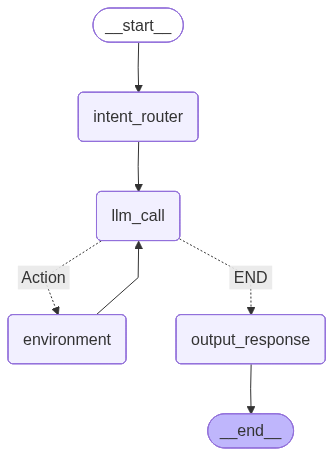

In [78]:
# Show the agent
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

### Agent Testing

In [36]:
checkpointer.get_tuple({"configurable": {"thread_id": "1"}})

In [37]:
callback_handler = TokensCallbackHandler()

In [38]:
question = "السلام عليكم انا محمد ايه الاخبار"

messages = agent.invoke(
    {"messages": [{"role": "user", "content": question}]},
    config={"callbacks": [callback_handler], "configurable": {"thread_id": "1"}, "recursion_limit": 10}
    )
messages

[INFO] Function search_kb() {'query': 'السلام عليكم انا محمد ايه الاخبار', 'k_results': 5, 'score_threshold': 0.1} Took 39.9517 seconds
[INFO] ---> Prompt Name:  - model_id: us.amazon.nova-pro-v1:0 - Input_Tokens: 1503 - Output_Tokens: 165 - Cost: 0.001730 - Time: 27.588 seconds


{'messages': [HumanMessage(content='السلام عليكم انا محمد ايه الاخبار', additional_kwargs={}, response_metadata={}, id='a9c13ddc-7d62-47c5-812c-aa3c0b0a94c2'),
  AIMessage(content='وعليكم السلام ورحمة الله وبركاته! \n\nأهلا وسهلا بك، محمد. أنا هنا لمساعدتك في أي استفسار لديك حول منتجاتنا، خططنا، خدماتنا، أو أي شيء آخر. كيف يمكنني مساعدتك اليوم؟\n\n**هل لديك أي أسئلة حول:**\n- خططنا وعروضنا؟\n- خدماتنا وميزاتها؟\n- الفواتير والدفع؟\n- طرق التواصل معنا؟\n\nأخبرني كيف يمكنني مساعدتك!\n\n**أسئلة قد تهمك:**\n- ما هي أحدث العروض التي تقدمها WE؟\n- كيف يمكنني التحقق من تفاصيل فاتورتي؟\n- ما هي الخدمات الإضافية التي يمكنني إضافتها إلى خطتي الحالية؟', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '8ba94722-f4b6-4804-a5ba-f2940915761f', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Sat, 18 Apr 2026 16:03:51 GMT', 'content-type': 'application/json', 'content-length': '1021', 'connection': 'keep-alive', 'x-amzn-requestid': '8ba94722-f4b6-4804-a5ba-f2940915761f'}, 'Re

In [39]:
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

السلام عليكم انا محمد ايه الاخبار
================================== Ai Message ==================================

وعليكم السلام ورحمة الله وبركاته! 

أهلا وسهلا بك، محمد. أنا هنا لمساعدتك في أي استفسار لديك حول منتجاتنا، خططنا، خدماتنا، أو أي شيء آخر. كيف يمكنني مساعدتك اليوم؟

**هل لديك أي أسئلة حول:**
- خططنا وعروضنا؟
- خدماتنا وميزاتها؟
- الفواتير والدفع؟
- طرق التواصل معنا؟

أخبرني كيف يمكنني مساعدتك!

**أسئلة قد تهمك:**
- ما هي أحدث العروض التي تقدمها WE؟
- كيف يمكنني التحقق من تفاصيل فاتورتي؟
- ما هي الخدمات الإضافية التي يمكنني إضافتها إلى خطتي الحالية؟


In [40]:
callback_handler.get_request_stats()

{'inut_tokens': 1503, 'output_tokens': 165, 'total_cost': 0.0017304}

In [41]:
callback_handler.get_total_stats()

{'us.amazon.nova-pro-v1:0': {'input_tokens': 22171,
  'output_tokens': 1330,
  'n_requests': 7,
  'total_cost': 0.021992}}

In [42]:
question = "طيب هو ايه وى دى اصلا وبتقدم خدمات ايه"

messages = agent.invoke(
    {"messages": [{"role": "user", "content": question}]},
    config={"callbacks": [callback_handler], "configurable": {"thread_id": "1"}, "recursion_limit": 10}
    )
messages

[INFO] Function search_kb() {'query': 'طيب هو ايه وى دى اصلا وبتقدم خدمات ايه', 'k_results': 5, 'score_threshold': 0.1} Took 0.2972 seconds
[INFO] ---> Prompt Name:  - model_id: us.amazon.nova-pro-v1:0 - Input_Tokens: 1708 - Output_Tokens: 26 - Cost: 0.001450 - Time: 0.848 seconds
[INFO] Function search_kb() {'query': 'ما هي WE وما هي الخدمات التي تقدمها؟', 'k_results': 5, 'score_threshold': 0.1} Took 0.2863 seconds
[INFO] ---> Prompt Name:  - model_id: us.amazon.nova-pro-v1:0 - Input_Tokens: 3001 - Output_Tokens: 458 - Cost: 0.003866 - Time: 4.038 seconds


{'messages': [HumanMessage(content='السلام عليكم انا محمد ايه الاخبار', additional_kwargs={}, response_metadata={}, id='a9c13ddc-7d62-47c5-812c-aa3c0b0a94c2'),
  AIMessage(content='وعليكم السلام ورحمة الله وبركاته! \n\nأهلا وسهلا بك، محمد. أنا هنا لمساعدتك في أي استفسار لديك حول منتجاتنا، خططنا، خدماتنا، أو أي شيء آخر. كيف يمكنني مساعدتك اليوم؟\n\n**هل لديك أي أسئلة حول:**\n- خططنا وعروضنا؟\n- خدماتنا وميزاتها؟\n- الفواتير والدفع؟\n- طرق التواصل معنا؟\n\nأخبرني كيف يمكنني مساعدتك!\n\n**أسئلة قد تهمك:**\n- ما هي أحدث العروض التي تقدمها WE؟\n- كيف يمكنني التحقق من تفاصيل فاتورتي؟\n- ما هي الخدمات الإضافية التي يمكنني إضافتها إلى خطتي الحالية؟', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '8ba94722-f4b6-4804-a5ba-f2940915761f', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Sat, 18 Apr 2026 16:03:51 GMT', 'content-type': 'application/json', 'content-length': '1021', 'connection': 'keep-alive', 'x-amzn-requestid': '8ba94722-f4b6-4804-a5ba-f2940915761f'}, 'Re

In [43]:
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

السلام عليكم انا محمد ايه الاخبار
================================== Ai Message ==================================

وعليكم السلام ورحمة الله وبركاته! 

أهلا وسهلا بك، محمد. أنا هنا لمساعدتك في أي استفسار لديك حول منتجاتنا، خططنا، خدماتنا، أو أي شيء آخر. كيف يمكنني مساعدتك اليوم؟

**هل لديك أي أسئلة حول:**
- خططنا وعروضنا؟
- خدماتنا وميزاتها؟
- الفواتير والدفع؟
- طرق التواصل معنا؟

أخبرني كيف يمكنني مساعدتك!

**أسئلة قد تهمك:**
- ما هي أحدث العروض التي تقدمها WE؟
- كيف يمكنني التحقق من تفاصيل فاتورتي؟
- ما هي الخدمات الإضافية التي يمكنني إضافتها إلى خطتي الحالية؟
================================ Human Message =================================

طيب هو ايه وى دى اصلا وبتقدم خدمات ايه
================================== Ai Message ==================================

[{'type': 'tool_use', 'name': 'search_kb', 'input': {'query': 'ما هي WE وما هي الخدمات التي تقدمها؟'}, 'id': 'tooluse_ERbO4ZGjeSecG7AIRS9812'}]
To

In [44]:
question = "طيب هو عندهم MIFI الى هو اجهزة الانترنت المنزلى"

messages = agent.invoke(
    {"messages": [{"role": "user", "content": question}]},
    config={"callbacks": [callback_handler], "configurable": {"thread_id": "1"}, "recursion_limit": 10}
    )
messages

[INFO] Function search_kb() {'query': 'طيب هو عندهم mifi الى هو اجهزة الانترنت المنزلى', 'k_results': 5, 'score_threshold': 0.1} Took 0.2665 seconds
[INFO] ---> Prompt Name:  - model_id: us.amazon.nova-pro-v1:0 - Input_Tokens: 3496 - Output_Tokens: 29 - Cost: 0.002890 - Time: 1.714 seconds
[INFO] Function search_kb() {'query': 'هل تقدم WE أجهزة MIFI للإنترنت المنزلي؟', 'k_results': 5, 'score_threshold': 0.1} Took 0.3073 seconds
[INFO] ---> Prompt Name:  - model_id: us.amazon.nova-pro-v1:0 - Input_Tokens: 4848 - Output_Tokens: 287 - Cost: 0.004797 - Time: 3.134 seconds


{'messages': [HumanMessage(content='السلام عليكم انا محمد ايه الاخبار', additional_kwargs={}, response_metadata={}, id='a9c13ddc-7d62-47c5-812c-aa3c0b0a94c2'),
  AIMessage(content='وعليكم السلام ورحمة الله وبركاته! \n\nأهلا وسهلا بك، محمد. أنا هنا لمساعدتك في أي استفسار لديك حول منتجاتنا، خططنا، خدماتنا، أو أي شيء آخر. كيف يمكنني مساعدتك اليوم؟\n\n**هل لديك أي أسئلة حول:**\n- خططنا وعروضنا؟\n- خدماتنا وميزاتها؟\n- الفواتير والدفع؟\n- طرق التواصل معنا؟\n\nأخبرني كيف يمكنني مساعدتك!\n\n**أسئلة قد تهمك:**\n- ما هي أحدث العروض التي تقدمها WE؟\n- كيف يمكنني التحقق من تفاصيل فاتورتي؟\n- ما هي الخدمات الإضافية التي يمكنني إضافتها إلى خطتي الحالية؟', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '8ba94722-f4b6-4804-a5ba-f2940915761f', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Sat, 18 Apr 2026 16:03:51 GMT', 'content-type': 'application/json', 'content-length': '1021', 'connection': 'keep-alive', 'x-amzn-requestid': '8ba94722-f4b6-4804-a5ba-f2940915761f'}, 'Re

In [45]:
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

السلام عليكم انا محمد ايه الاخبار
================================== Ai Message ==================================

وعليكم السلام ورحمة الله وبركاته! 

أهلا وسهلا بك، محمد. أنا هنا لمساعدتك في أي استفسار لديك حول منتجاتنا، خططنا، خدماتنا، أو أي شيء آخر. كيف يمكنني مساعدتك اليوم؟

**هل لديك أي أسئلة حول:**
- خططنا وعروضنا؟
- خدماتنا وميزاتها؟
- الفواتير والدفع؟
- طرق التواصل معنا؟

أخبرني كيف يمكنني مساعدتك!

**أسئلة قد تهمك:**
- ما هي أحدث العروض التي تقدمها WE؟
- كيف يمكنني التحقق من تفاصيل فاتورتي؟
- ما هي الخدمات الإضافية التي يمكنني إضافتها إلى خطتي الحالية؟
================================ Human Message =================================

طيب هو ايه وى دى اصلا وبتقدم خدمات ايه
================================== Ai Message ==================================

[{'type': 'tool_use', 'name': 'search_kb', 'input': {'query': 'ما هي WE وما هي الخدمات التي تقدمها؟'}, 'id': 'tooluse_ERbO4ZGjeSecG7AIRS9812'}]
To

In [46]:
question = "بكام ال اجهزة MIFI"

messages = agent.invoke(
    {"messages": [{"role": "user", "content": question}]},
    config={"callbacks": [callback_handler], "configurable": {"thread_id": "1"}, "recursion_limit": 10}
    )
messages

[INFO] Function search_kb() {'query': 'بكام ال اجهزة mifi', 'k_results': 5, 'score_threshold': 0.1} Took 0.2808 seconds
[INFO] ---> Prompt Name:  - model_id: us.amazon.nova-pro-v1:0 - Input_Tokens: 5147 - Output_Tokens: 181 - Cost: 0.004697 - Time: 2.419 seconds


{'messages': [HumanMessage(content='السلام عليكم انا محمد ايه الاخبار', additional_kwargs={}, response_metadata={}, id='a9c13ddc-7d62-47c5-812c-aa3c0b0a94c2'),
  AIMessage(content='وعليكم السلام ورحمة الله وبركاته! \n\nأهلا وسهلا بك، محمد. أنا هنا لمساعدتك في أي استفسار لديك حول منتجاتنا، خططنا، خدماتنا، أو أي شيء آخر. كيف يمكنني مساعدتك اليوم؟\n\n**هل لديك أي أسئلة حول:**\n- خططنا وعروضنا؟\n- خدماتنا وميزاتها؟\n- الفواتير والدفع؟\n- طرق التواصل معنا؟\n\nأخبرني كيف يمكنني مساعدتك!\n\n**أسئلة قد تهمك:**\n- ما هي أحدث العروض التي تقدمها WE؟\n- كيف يمكنني التحقق من تفاصيل فاتورتي؟\n- ما هي الخدمات الإضافية التي يمكنني إضافتها إلى خطتي الحالية؟', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '8ba94722-f4b6-4804-a5ba-f2940915761f', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Sat, 18 Apr 2026 16:03:51 GMT', 'content-type': 'application/json', 'content-length': '1021', 'connection': 'keep-alive', 'x-amzn-requestid': '8ba94722-f4b6-4804-a5ba-f2940915761f'}, 'Re

In [47]:
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

السلام عليكم انا محمد ايه الاخبار
================================== Ai Message ==================================

وعليكم السلام ورحمة الله وبركاته! 

أهلا وسهلا بك، محمد. أنا هنا لمساعدتك في أي استفسار لديك حول منتجاتنا، خططنا، خدماتنا، أو أي شيء آخر. كيف يمكنني مساعدتك اليوم؟

**هل لديك أي أسئلة حول:**
- خططنا وعروضنا؟
- خدماتنا وميزاتها؟
- الفواتير والدفع؟
- طرق التواصل معنا؟

أخبرني كيف يمكنني مساعدتك!

**أسئلة قد تهمك:**
- ما هي أحدث العروض التي تقدمها WE؟
- كيف يمكنني التحقق من تفاصيل فاتورتي؟
- ما هي الخدمات الإضافية التي يمكنني إضافتها إلى خطتي الحالية؟
================================ Human Message =================================

طيب هو ايه وى دى اصلا وبتقدم خدمات ايه
================================== Ai Message ==================================

[{'type': 'tool_use', 'name': 'search_kb', 'input': {'query': 'ما هي WE وما هي الخدمات التي تقدمها؟'}, 'id': 'tooluse_ERbO4ZGjeSecG7AIRS9812'}]
To

In [48]:
question = "طيب ايه باقات we gold  المتاحه"

messages = agent.invoke(
    {"messages": [{"role": "user", "content": question}]},
    config={"callbacks": [callback_handler], "configurable": {"thread_id": "1"}, "recursion_limit": 10}
    )
messages

[INFO] Function search_kb() {'query': 'طيب ايه باقات we gold  المتاحه', 'k_results': 5, 'score_threshold': 0.1} Took 0.3059 seconds
[INFO] ---> Prompt Name:  - model_id: us.amazon.nova-pro-v1:0 - Input_Tokens: 5362 - Output_Tokens: 24 - Cost: 0.004366 - Time: 1.088 seconds
[INFO] Function search_kb() {'query': 'ما هي باقات WE Gold المتاحة؟', 'k_results': 5, 'score_threshold': 0.1} Took 0.3073 seconds
[INFO] ---> Prompt Name:  - model_id: us.amazon.nova-pro-v1:0 - Input_Tokens: 6788 - Output_Tokens: 408 - Cost: 0.006736 - Time: 5.132 seconds


{'messages': [HumanMessage(content='السلام عليكم انا محمد ايه الاخبار', additional_kwargs={}, response_metadata={}, id='a9c13ddc-7d62-47c5-812c-aa3c0b0a94c2'),
  AIMessage(content='وعليكم السلام ورحمة الله وبركاته! \n\nأهلا وسهلا بك، محمد. أنا هنا لمساعدتك في أي استفسار لديك حول منتجاتنا، خططنا، خدماتنا، أو أي شيء آخر. كيف يمكنني مساعدتك اليوم؟\n\n**هل لديك أي أسئلة حول:**\n- خططنا وعروضنا؟\n- خدماتنا وميزاتها؟\n- الفواتير والدفع؟\n- طرق التواصل معنا؟\n\nأخبرني كيف يمكنني مساعدتك!\n\n**أسئلة قد تهمك:**\n- ما هي أحدث العروض التي تقدمها WE؟\n- كيف يمكنني التحقق من تفاصيل فاتورتي؟\n- ما هي الخدمات الإضافية التي يمكنني إضافتها إلى خطتي الحالية؟', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '8ba94722-f4b6-4804-a5ba-f2940915761f', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Sat, 18 Apr 2026 16:03:51 GMT', 'content-type': 'application/json', 'content-length': '1021', 'connection': 'keep-alive', 'x-amzn-requestid': '8ba94722-f4b6-4804-a5ba-f2940915761f'}, 'Re

In [49]:
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

السلام عليكم انا محمد ايه الاخبار
================================== Ai Message ==================================

وعليكم السلام ورحمة الله وبركاته! 

أهلا وسهلا بك، محمد. أنا هنا لمساعدتك في أي استفسار لديك حول منتجاتنا، خططنا، خدماتنا، أو أي شيء آخر. كيف يمكنني مساعدتك اليوم؟

**هل لديك أي أسئلة حول:**
- خططنا وعروضنا؟
- خدماتنا وميزاتها؟
- الفواتير والدفع؟
- طرق التواصل معنا؟

أخبرني كيف يمكنني مساعدتك!

**أسئلة قد تهمك:**
- ما هي أحدث العروض التي تقدمها WE؟
- كيف يمكنني التحقق من تفاصيل فاتورتي؟
- ما هي الخدمات الإضافية التي يمكنني إضافتها إلى خطتي الحالية؟
================================ Human Message =================================

طيب هو ايه وى دى اصلا وبتقدم خدمات ايه
================================== Ai Message ==================================

[{'type': 'tool_use', 'name': 'search_kb', 'input': {'query': 'ما هي WE وما هي الخدمات التي تقدمها؟'}, 'id': 'tooluse_ERbO4ZGjeSecG7AIRS9812'}]
To

### Parse Files

In [207]:
import fitz  
import docx
from pathlib import Path
from bs4 import BeautifulSoup

def extract_text_from_file(file_path: str):
    # 1. Get extension
    ext = Path(file_path).suffix.lower().lstrip('.')
    text = ""

    # 2. Parse based on type
    if ext == "pdf":
        with fitz.open(file_path) as doc:
            # Efficiently join text from all pages
            text = chr(12).join([page.get_text() for page in doc])
            
    elif ext == "docx":
        doc_obj = docx.Document(file_path)
        text = "\n".join([para.text for para in doc_obj.paragraphs])
        
    elif ext == "html":
        with open(file_path, "r", encoding="utf-8") as f:
            text = BeautifulSoup(f, "html.parser").get_text(separator="\n")
            
    elif ext == "txt":
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()
    
    else:
        print(f"[WARNING] Unsupported format: {file_path}")
    
    # 3. Count Words & Tokens
    word_count = len(text.split())
    token_est = int(word_count * 1.5)
    
    return text, word_count, token_est

In [212]:
test_files = [
    r"tmp\test_1.txt",
    r"tmp\test_2.docx",
    r"tmp\test_3.pdf",
    r"tmp\test_4.html"
]

for i in test_files:
    print(extract_text_from_file(i))

('test_file_1\n\nBuild a production-ready RAG-powered intelligent chatbot for Telecom Egypt that answers customer queries using the official website as the primary knowledge base. The system must support multi-lingual processing (Arabic and English), handle Egyptian dialect variations, and allow users to upload documents for querying.', 44, 66)
('Test_file_2', 1, 1)
('Test_file_3 \n', 1, 1)
('test_file_4', 1, 1)


In [213]:
extract_text_from_file(r"Telecom Egypt Intelligent Assistant.pdf")

(' \nChatbot Case Study \nTelecom Egypt Intelligent Assistant  \nOverview \nBuild a production-ready RAG-powered intelligent chatbot for Telecom Egypt that answers \ncustomer queries using the official website as the primary knowledge base. The system must \nsupport multi-lingual processing (Arabic and English), handle Egyptian dialect variations, and allow \nusers to upload documents for querying. \nScenario \nTelecom Egypt receives thousands of customer inquiries daily about services, plans, bills, and \ntechnical support. The company wants to deploy an AI-powered chatbot that can: \n1. Answers customer questions using Telecom Egypt official website \n2. Handles queries in Arabic, English, and Egyptian dialect \n3. Allow users to upload and query additional documents (PDF, DOCX, TXT, HTML, Images) \n4. All responses must be grounded and bounded by the Telecom Egypt website \n5. Provides source citations for all answers \n6. Delivers a professional chat interface \nKnowledge Sources \

### Draft